<a href="https://colab.research.google.com/github/gauravjha201/Deep_Learning_practices/blob/main/DL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

(train_images,train_labels),(_,_)=fashion_mnist.load_data()

train_images=train_images.reshape(train_images.shape[0],28,28,1)

train_images=train_images.astype('float32')

train_images=(train_images-127.5)/127.5

BUFFER_SIZE=60000
BATCH_SIZE=128

dataset=tf.data.Dataset.from_tensor_slices(train_images)
dataset=dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


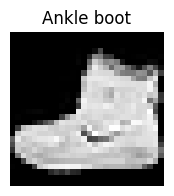

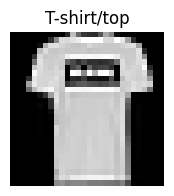

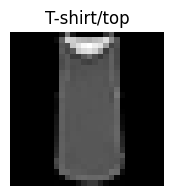

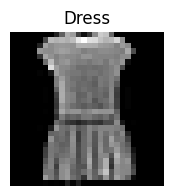

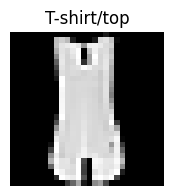

In [20]:
mnist_class_name=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
def show_image(index):
  if index<0 or index>=len(train_images):
    print("index out of range")
    return
  image=train_images[index]
  label=train_labels[index]
  class_name=mnist_class_name[label]

  plt.figure(figsize=(2,2))
  plt.imshow(image,cmap='gray')
  plt.title(class_name)
  plt.axis('off')
  plt.show()


for i in range(5):
  show_image(i)

In [3]:
from tensorflow.keras import layers
def build_generator(latent_dim):
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7,7,256)),

        layers.Conv2DTranspose(128,(5,5),strides=(1,1),padding='same',use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64,(5,5),strides=(2,2),padding='same',use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1,(5,5),strides=(2,2),padding='same',use_bias=False,activation='tanh')
    ])

    return model

In [4]:
def build_discriminator():

    model = tf.keras.Sequential([
        layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=(28,28,1)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128,(5,5),strides=(2,2),padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])

    return model

In [5]:
cross_entropy =tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  return real_loss+fake_loss

def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output),fake_output)

generator=build_generator(100)
discriminator=build_discriminator()

gen_optimizer=tf.keras.optimizers.Adam(1e-4)
disc_optimizer=tf.keras.optimizers.Adam(1e-4)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
@tf.function
def train_step(images):
  noise=tf.random.normal([BATCH_SIZE,100])

  with tf.GradientTape() as gen_tape,tf.GradientTape() as disc_tape:
    generated_images=generator(noise,training=True)

    real_output=discriminator(images,training=True)
    fake_output=discriminator(generated_images,training=True)

    gen_loss=generator_loss(fake_output)
    disc_loss=discriminator_loss(real_output,fake_output)

  gradient_gen=gen_tape.gradient(gen_loss,generator.trainable_variables)
  gradient_disc=disc_tape.gradient(disc_loss,discriminator.trainable_variables)

  gen_optimizer.apply_gradients(zip(gradient_gen,generator.trainable_variables))
  disc_optimizer.apply_gradients(zip(gradient_disc,discriminator.trainable_variables))

  return gen_loss,disc_loss




In [8]:
def generate_and_save_images(model,epoch):
  noise=tf.random.normal([16,100])
  predictions=model(noise,training=False)

  fig=plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow((predictions[i,:,:,0]+1)/2,cmap='gray')
    plt.axis('off')

  plt.suptitle(f'Epoch {epoch}')
  plt.show()



Epoch 1, Gen Loss: 1.2047, Disc Loss: 1.0847
Epoch 2, Gen Loss: 1.0145, Disc Loss: 1.0963
Epoch 3, Gen Loss: 1.0635, Disc Loss: 1.2733
Epoch 4, Gen Loss: 1.1153, Disc Loss: 1.0996
Epoch 5, Gen Loss: 0.9573, Disc Loss: 1.1800
Epoch 6, Gen Loss: 1.1439, Disc Loss: 1.0383
Epoch 7, Gen Loss: 0.9139, Disc Loss: 1.3156
Epoch 8, Gen Loss: 0.9639, Disc Loss: 1.1557
Epoch 9, Gen Loss: 1.0370, Disc Loss: 1.1413
Epoch 10, Gen Loss: 1.0099, Disc Loss: 1.2105


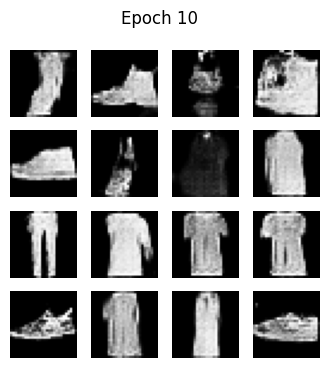

Epoch 11, Gen Loss: 0.8503, Disc Loss: 1.2949
Epoch 12, Gen Loss: 0.8665, Disc Loss: 1.3772
Epoch 13, Gen Loss: 1.0078, Disc Loss: 1.2491
Epoch 14, Gen Loss: 0.8916, Disc Loss: 1.3435
Epoch 15, Gen Loss: 1.0392, Disc Loss: 1.1162
Epoch 16, Gen Loss: 0.9151, Disc Loss: 1.1834
Epoch 17, Gen Loss: 0.8513, Disc Loss: 1.2862
Epoch 18, Gen Loss: 0.9798, Disc Loss: 1.2572
Epoch 19, Gen Loss: 0.9302, Disc Loss: 1.2964
Epoch 20, Gen Loss: 0.7890, Disc Loss: 1.2074


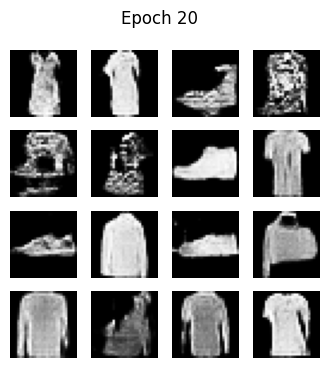

Epoch 21, Gen Loss: 1.8977, Disc Loss: 0.4965
Epoch 22, Gen Loss: 0.9507, Disc Loss: 1.0981
Epoch 23, Gen Loss: 1.2585, Disc Loss: 0.9389
Epoch 24, Gen Loss: 0.9141, Disc Loss: 1.2384
Epoch 25, Gen Loss: 0.9463, Disc Loss: 1.2087
Epoch 26, Gen Loss: 0.8880, Disc Loss: 1.2584
Epoch 27, Gen Loss: 1.0181, Disc Loss: 1.2497
Epoch 28, Gen Loss: 1.0894, Disc Loss: 1.1949
Epoch 29, Gen Loss: 0.9309, Disc Loss: 1.2129
Epoch 30, Gen Loss: 0.9023, Disc Loss: 1.2544


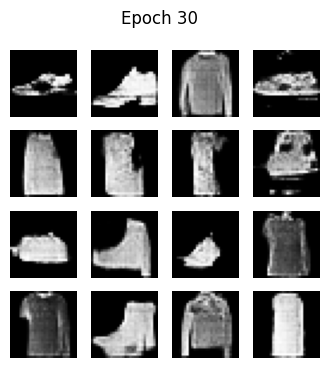

Epoch 31, Gen Loss: 0.9180, Disc Loss: 1.3118
Epoch 32, Gen Loss: 0.9746, Disc Loss: 1.2088
Epoch 33, Gen Loss: 0.9253, Disc Loss: 1.2319
Epoch 34, Gen Loss: 0.9369, Disc Loss: 1.1786
Epoch 35, Gen Loss: 0.8193, Disc Loss: 1.1945
Epoch 36, Gen Loss: 0.9701, Disc Loss: 1.1650
Epoch 37, Gen Loss: 0.8184, Disc Loss: 1.2735
Epoch 38, Gen Loss: 0.9426, Disc Loss: 1.2616
Epoch 39, Gen Loss: 0.8897, Disc Loss: 1.2823
Epoch 40, Gen Loss: 0.9302, Disc Loss: 1.2030


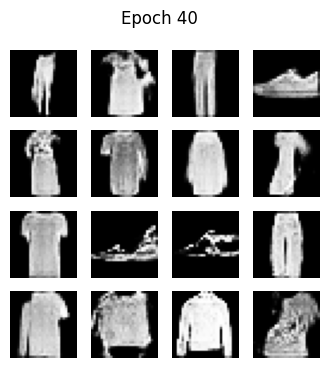

Epoch 41, Gen Loss: 0.9690, Disc Loss: 1.2346
Epoch 42, Gen Loss: 1.3492, Disc Loss: 0.8162
Epoch 43, Gen Loss: 1.5279, Disc Loss: 0.7804
Epoch 44, Gen Loss: 1.0229, Disc Loss: 1.2512
Epoch 45, Gen Loss: 0.9129, Disc Loss: 1.1925
Epoch 46, Gen Loss: 1.0447, Disc Loss: 1.2097
Epoch 47, Gen Loss: 1.0722, Disc Loss: 1.2820
Epoch 48, Gen Loss: 0.9619, Disc Loss: 1.2841
Epoch 49, Gen Loss: 0.9489, Disc Loss: 1.2311
Epoch 50, Gen Loss: 0.9125, Disc Loss: 1.2100


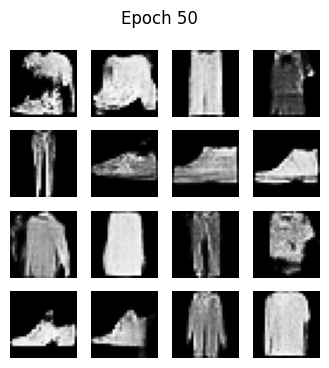

Epoch 51, Gen Loss: 1.0057, Disc Loss: 1.2622
Epoch 52, Gen Loss: 0.8260, Disc Loss: 1.2845
Epoch 53, Gen Loss: 0.9037, Disc Loss: 1.3291
Epoch 54, Gen Loss: 0.8760, Disc Loss: 1.2650
Epoch 55, Gen Loss: 0.9219, Disc Loss: 1.2950
Epoch 56, Gen Loss: 0.9646, Disc Loss: 1.1208
Epoch 57, Gen Loss: 0.8826, Disc Loss: 1.2195
Epoch 58, Gen Loss: 0.9635, Disc Loss: 1.2247
Epoch 59, Gen Loss: 0.9680, Disc Loss: 1.2443
Epoch 60, Gen Loss: 0.9525, Disc Loss: 1.2414


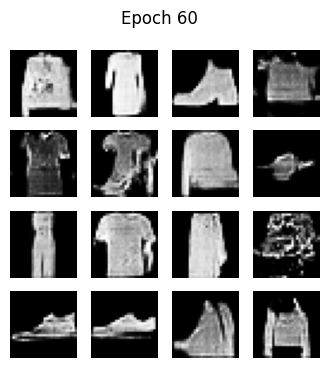

Epoch 61, Gen Loss: 1.0013, Disc Loss: 1.2247
Epoch 62, Gen Loss: 0.8133, Disc Loss: 1.3552
Epoch 63, Gen Loss: 1.0128, Disc Loss: 1.2688
Epoch 64, Gen Loss: 0.9315, Disc Loss: 1.2292
Epoch 65, Gen Loss: 0.9108, Disc Loss: 1.2069
Epoch 66, Gen Loss: 1.7404, Disc Loss: 0.7786
Epoch 67, Gen Loss: 1.0182, Disc Loss: 1.1998
Epoch 68, Gen Loss: 0.8716, Disc Loss: 1.3688
Epoch 69, Gen Loss: 0.9367, Disc Loss: 1.2486
Epoch 70, Gen Loss: 0.8796, Disc Loss: 1.2140


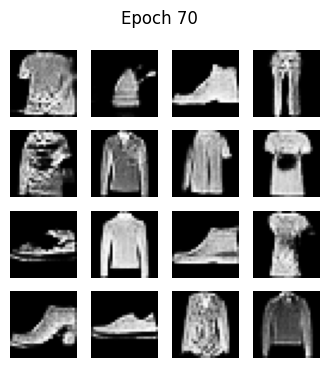

Epoch 71, Gen Loss: 0.8167, Disc Loss: 1.2853
Epoch 72, Gen Loss: 0.8379, Disc Loss: 1.1910
Epoch 73, Gen Loss: 0.8631, Disc Loss: 1.3442
Epoch 74, Gen Loss: 1.0537, Disc Loss: 1.2556
Epoch 75, Gen Loss: 0.9305, Disc Loss: 1.2629
Epoch 76, Gen Loss: 0.9764, Disc Loss: 1.2486
Epoch 77, Gen Loss: 1.0221, Disc Loss: 1.3137
Epoch 78, Gen Loss: 1.2518, Disc Loss: 1.1575
Epoch 79, Gen Loss: 1.1848, Disc Loss: 1.1462
Epoch 80, Gen Loss: 0.8630, Disc Loss: 1.2318


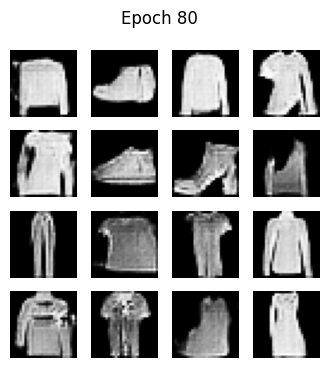

Epoch 81, Gen Loss: 0.9308, Disc Loss: 1.2694
Epoch 82, Gen Loss: 0.9029, Disc Loss: 1.2788
Epoch 83, Gen Loss: 0.8731, Disc Loss: 1.2838
Epoch 84, Gen Loss: 0.8907, Disc Loss: 1.3565
Epoch 85, Gen Loss: 1.0025, Disc Loss: 1.2590
Epoch 86, Gen Loss: 1.0319, Disc Loss: 1.2294
Epoch 87, Gen Loss: 0.9251, Disc Loss: 1.2247
Epoch 88, Gen Loss: 0.8614, Disc Loss: 1.3096
Epoch 89, Gen Loss: 0.8418, Disc Loss: 1.3310
Epoch 90, Gen Loss: 0.7381, Disc Loss: 1.2873


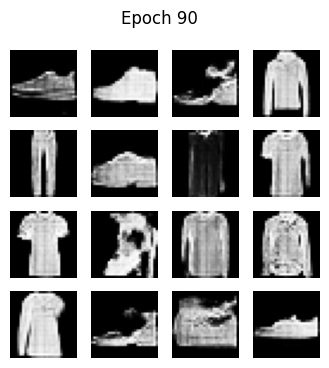

Epoch 91, Gen Loss: 0.9179, Disc Loss: 1.2510
Epoch 92, Gen Loss: 0.9858, Disc Loss: 1.2319
Epoch 93, Gen Loss: 0.8625, Disc Loss: 1.3515
Epoch 94, Gen Loss: 0.8279, Disc Loss: 1.3154
Epoch 95, Gen Loss: 0.8406, Disc Loss: 1.3748
Epoch 96, Gen Loss: 0.9638, Disc Loss: 1.1895
Epoch 97, Gen Loss: 1.5083, Disc Loss: 0.8264
Epoch 98, Gen Loss: 1.0215, Disc Loss: 1.3273
Epoch 99, Gen Loss: 0.9178, Disc Loss: 1.3545
Epoch 100, Gen Loss: 1.0851, Disc Loss: 1.2568


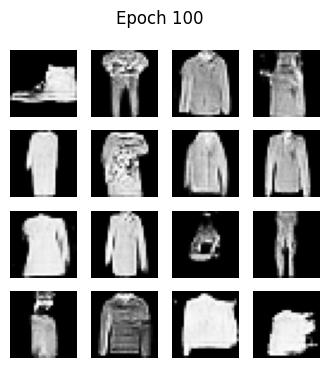

In [21]:
EPOCHS=100

gen_losses=[]
disc_losses=[]

for epoch in range(EPOCHS):
    for image_batch in dataset:
        g_loss,d_loss=train_step(image_batch)

    gen_losses.append(g_loss.numpy())
    disc_losses.append(d_loss.numpy())

    print(f"Epoch {epoch+1}, Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")

    if (epoch+1) % 10 == 0:
        generate_and_save_images(generator, epoch+1)

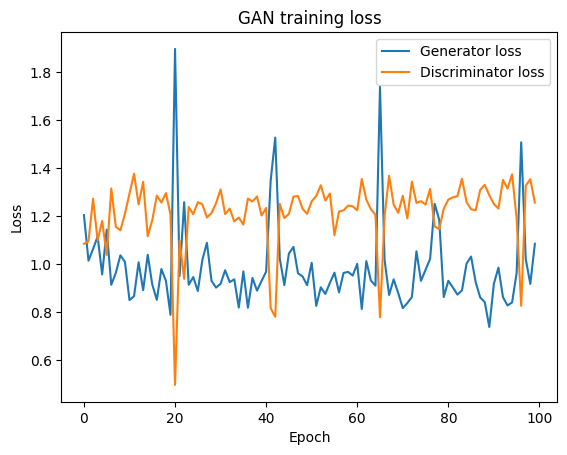

In [22]:
plt.plot(gen_losses,label="Generator loss")
plt.plot(disc_losses,label="Discriminator loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training loss")
plt.show()

